# Grouped Penetration Models: Axial And Radial

This notebook trains geometry-aware penetration models.

Models:

- axial model on top and bottom components, target `z_from_center`
- radial model on side components, target `r`

This keeps the target aligned with the expected penetration direction for each detector region.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "prepare_resum_data.py").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

EXPERIMENT_DIR = REPO_ROOT / "depth_penetration_experiments"
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from depth_vbll import (
    component_summary_table,
    load_depth_dataset,
    plot_component_depth_heatmap,
    plot_component_error_bars,
    plot_component_initial_positions,
    plot_component_penetration_ranking,
    plot_prediction_parity,
    plot_target_distributions,
    plot_training_history,
    run_vbll_regression,
)

DATA_DIR = REPO_ROOT / "data"
MAX_ROWS_PER_COMPONENT = 25000
EPOCHS = 40
BATCH_SIZE = 512
AXIAL_ARTIFACT_DIR = EXPERIMENT_DIR / "artifacts" / "axial_penetration"
RADIAL_ARTIFACT_DIR = EXPERIMENT_DIR / "artifacts" / "radial_penetration"

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Max rows per component: {MAX_ROWS_PER_COMPONENT}")


Repo root: /home/klz/Data/XLZD/anpatnaik
Data dir: /home/klz/Data/XLZD/anpatnaik/data
Max rows per component: 25000


## 1. Load Data And Confirm Component Grouping

In [2]:
dataset = load_depth_dataset(DATA_DIR, max_rows_per_component=MAX_ROWS_PER_COMPONENT)
df = dataset.df.copy()
summary_df = component_summary_table(df)
axial_df = df[df["component_group"].isin(["top", "bottom"])].copy()
radial_df = df[df["component_group"] == "side"].copy()

print(f"Rows loaded: {len(df):,}")
print(f"Axial rows: {len(axial_df):,}")
print(f"Radial rows: {len(radial_df):,}")
print(f"Fixed z_center: {dataset.z_center:.6f}")
print(f"Fixed TPC limits: R_max={dataset.r_max:.1f}, Z_max={dataset.z_max:.1f}")
display(summary_df)


Loading event files:   0%|          | 0/7 [00:00<?, ?it/s]

Rows loaded: 175,000
Axial rows: 100,000
Radial rows: 75,000
Inferred z_center: 1982.508220


,source_component,component_group,event_count,sx_mean,sy_mean,sz_centered_mean,r_mean,z_from_center_mean,d_center_mean,d_center_p01
0,CathodeGrid,bottom,25000,-1.056260,-6.084838,-1982.491444,975.212240,1935.659535,2190.870083,1854.961821
5,TPCPMTTBottom,bottom,25000,1.353462,5.194269,-2168.205036,959.761045,1909.800943,2160.756349,1796.466151
1,FieldCage,side,25000,2.803467,-0.105762,-28.592162,1440.012288,1000.763530,1818.323596,1330.756447
3,ICV,side,25000,0.628476,2.374358,1355.598978,1239.223157,1432.779489,1994.114443,1338.659774
4,OCV,side,25000,-6.462084,-5.812304,1065.895680,1264.901704,1264.019844,1898.888996,1308.916241
2,GXe,top,25000,-4.507360,-3.219266,2382.724718,944.805380,1922.686698,2166.475829,1820.036321
6,TPCPMTTop,top,25000,1.575866,-3.365886,2087.186939,950.566568,1927.927586,2172.733450,1826.247713


## 2. Axial-Penetration Data Views

Top and bottom components are modeled against `z_from_center`.

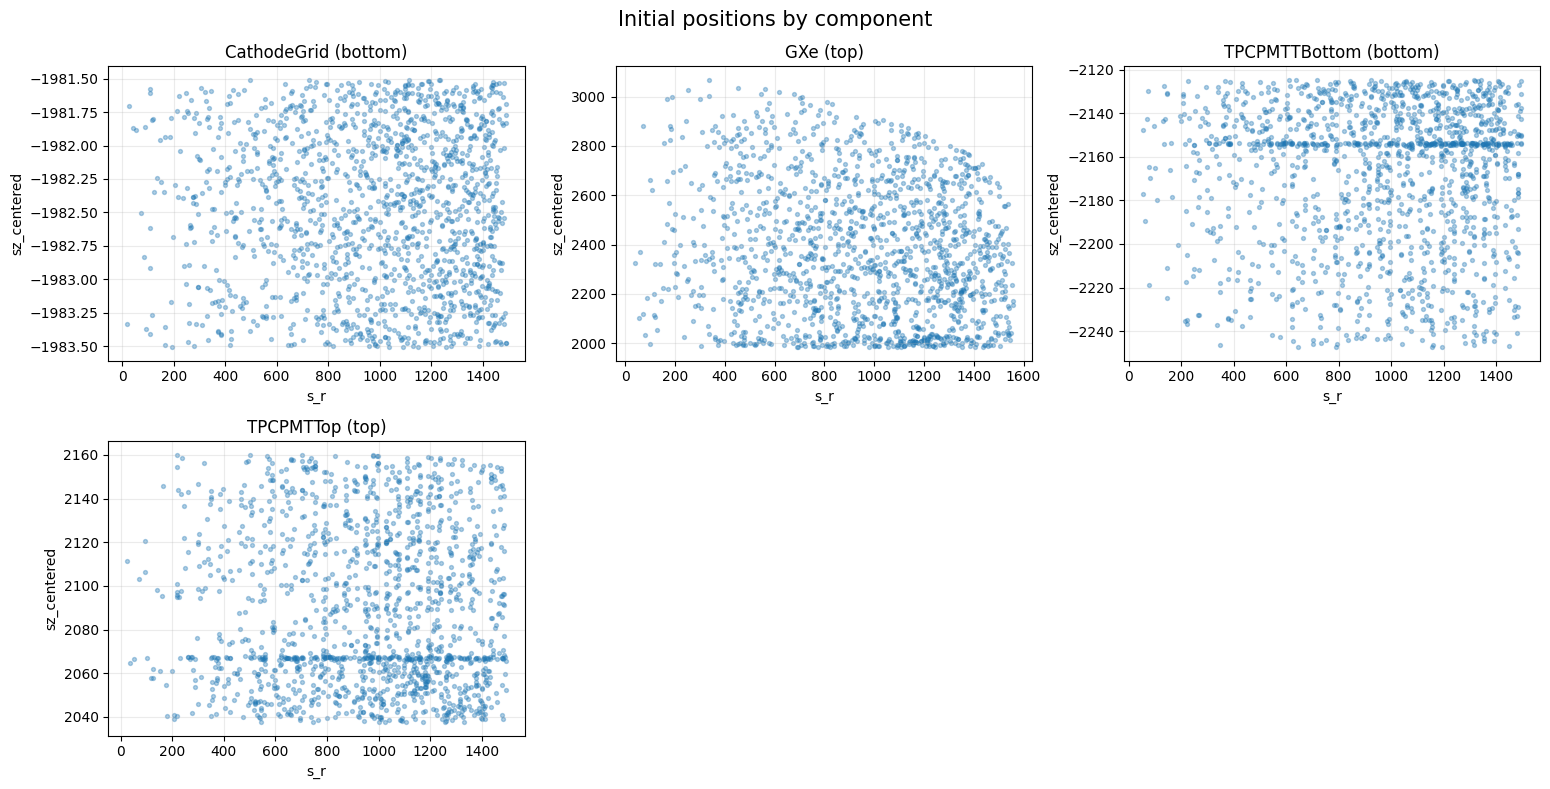

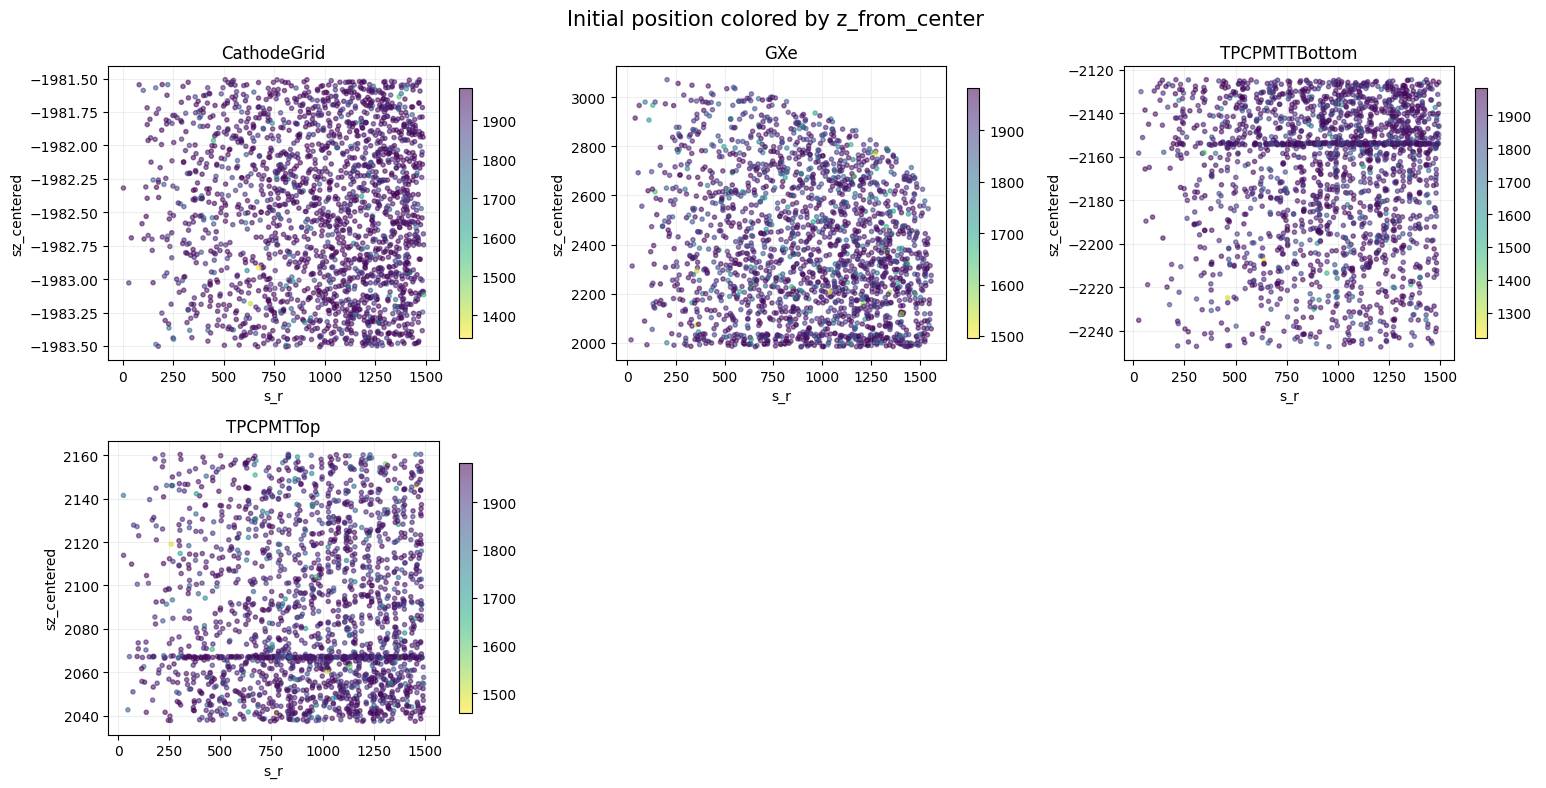

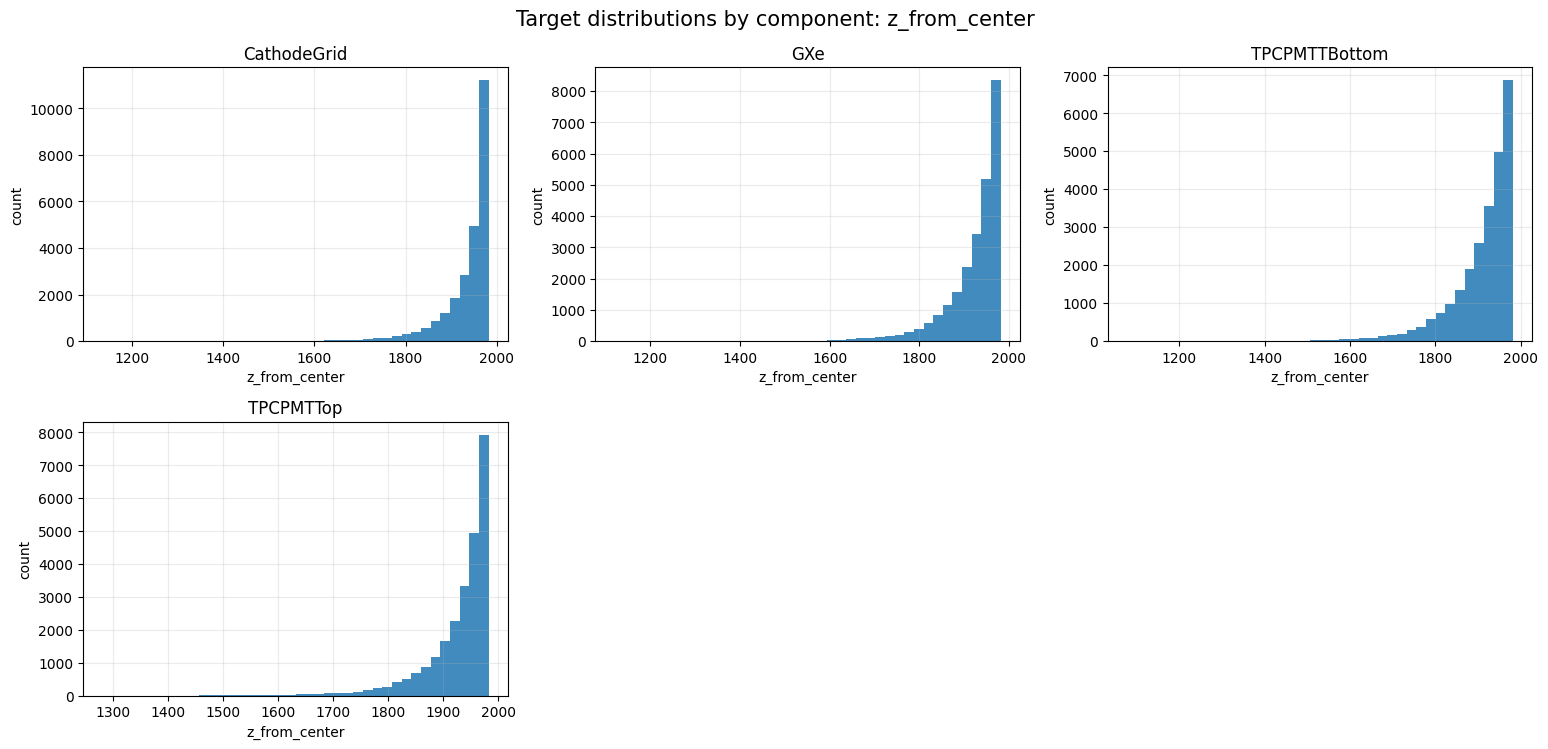

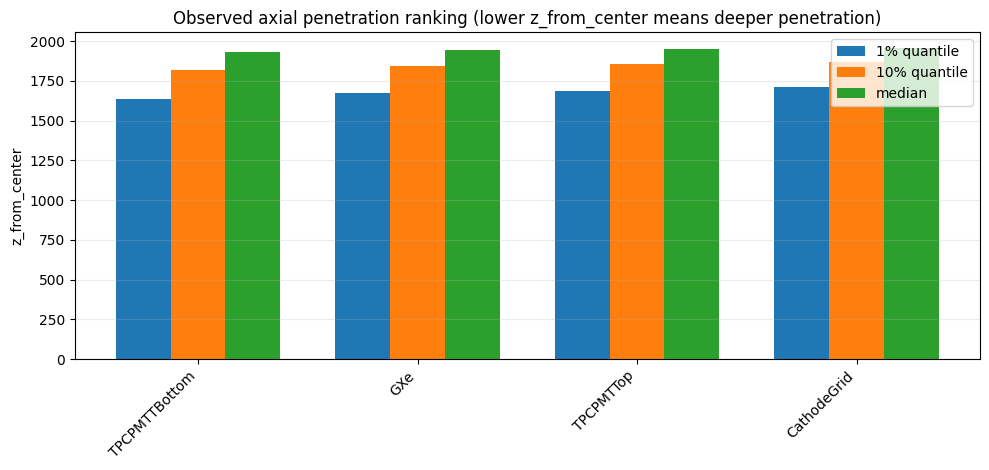

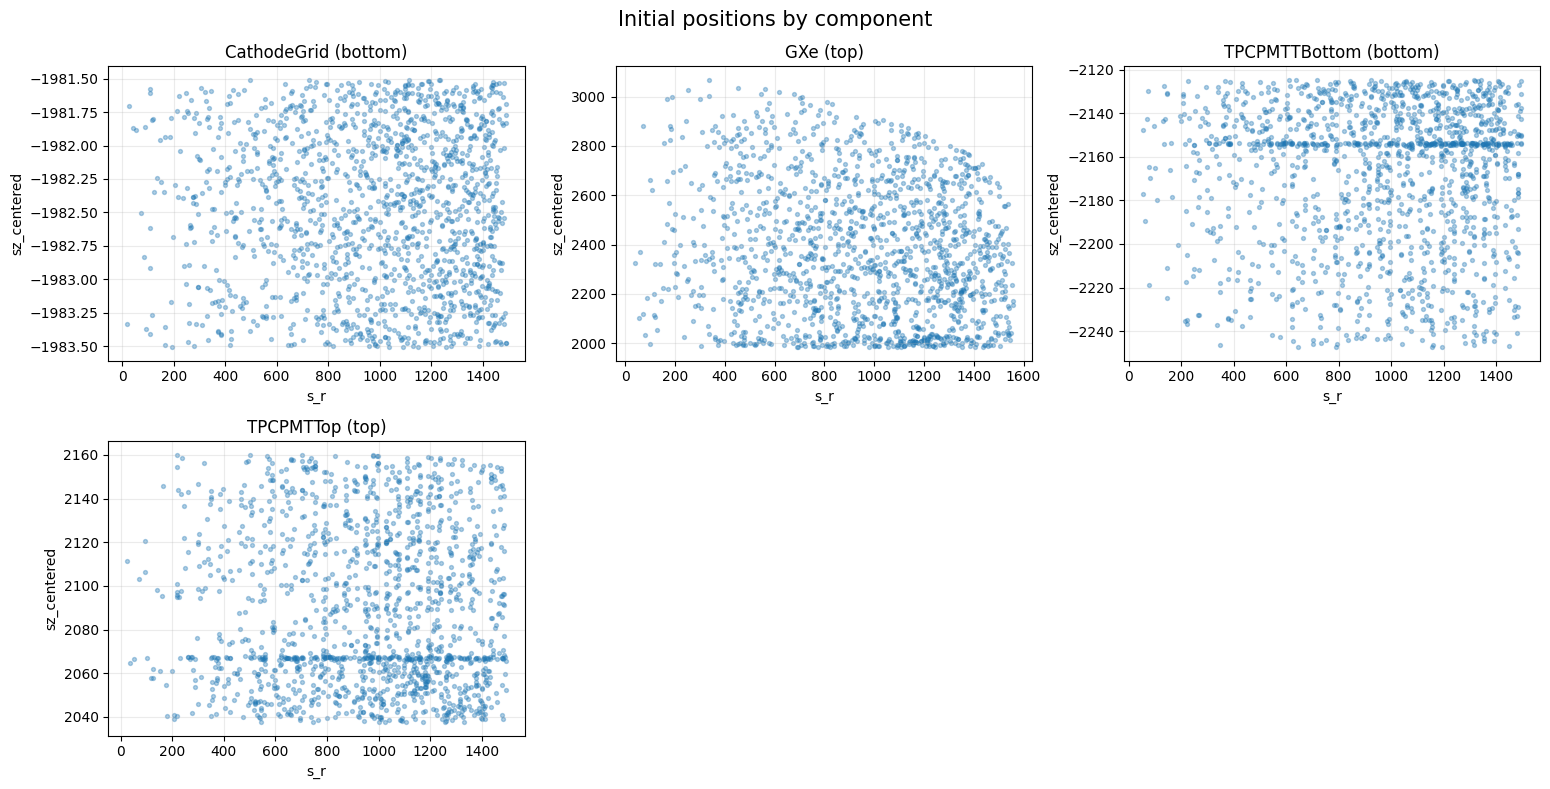

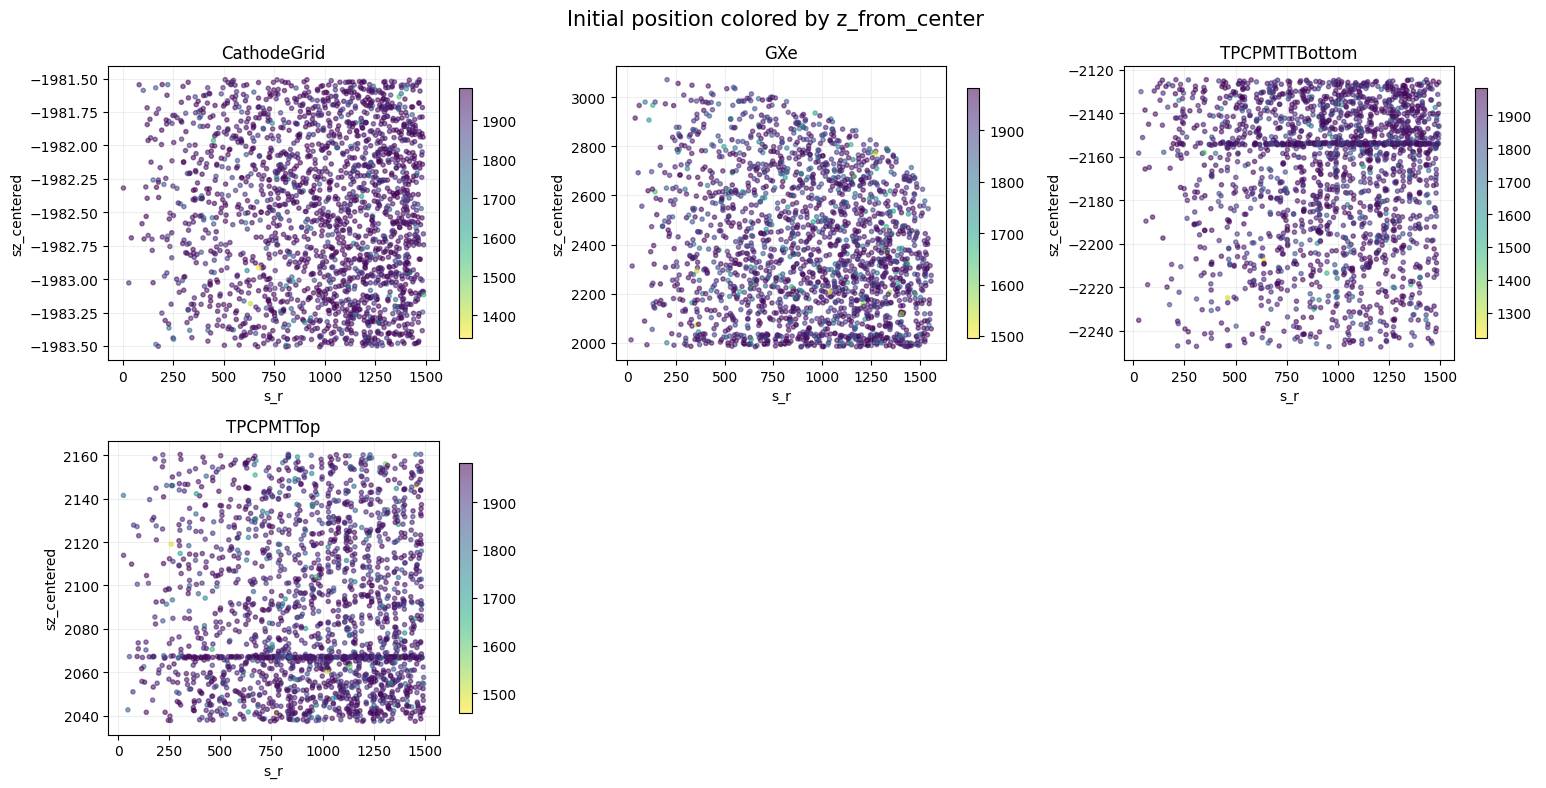

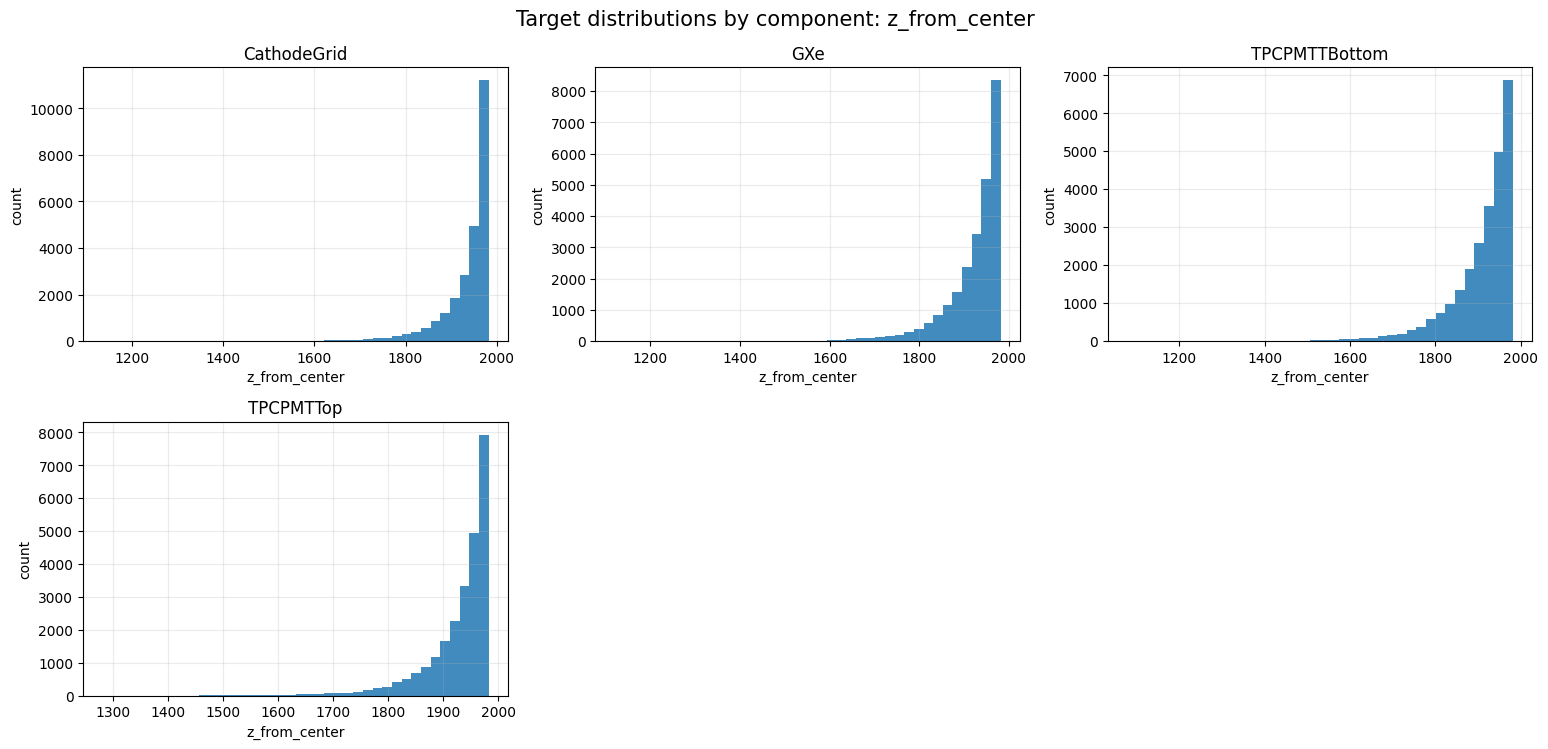

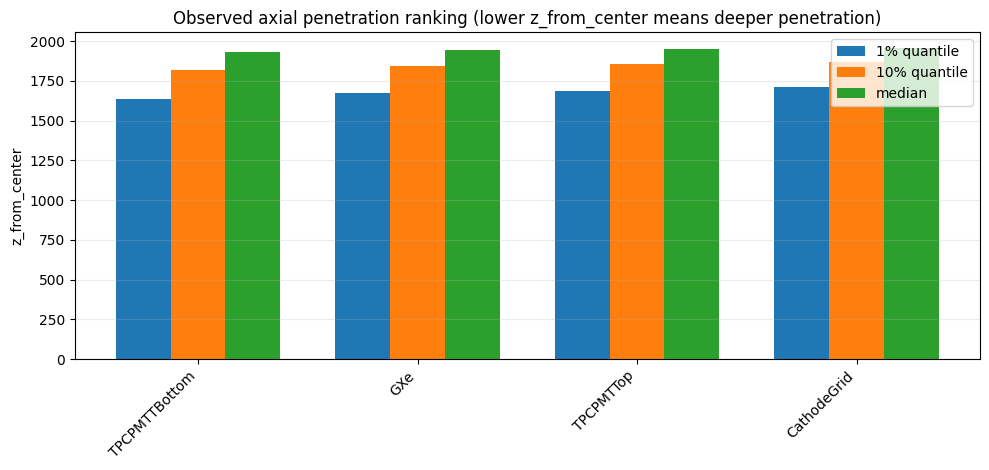

In [3]:
fig = plot_component_initial_positions(axial_df)
display(fig)
plt.close(fig)

fig = plot_component_depth_heatmap(axial_df, target_col="z_from_center")
display(fig)
plt.close(fig)

fig = plot_target_distributions(axial_df, target_col="z_from_center")
display(fig)
plt.close(fig)

fig = plot_component_penetration_ranking(
    axial_df,
    target_col="z_from_center",
    title="Observed axial penetration ranking (lower z_from_center means deeper penetration)",
)
display(fig)
plt.close(fig)


## 3. Train The Axial Model

In [4]:
axial_result = run_vbll_regression(
    axial_df,
    target_name="z_from_center",
    model_dir=AXIAL_ARTIFACT_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

display(pd.DataFrame([axial_result.metrics]))
print(f"Saved model artifacts: {axial_result.model_dir}")


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2/40:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 3/40:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 4/40:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 38/40:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 39/40:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 40/40:   0%|          | 0/157 [00:00<?, ?it/s]

,mae,rmse,r2,coverage_1sigma,coverage_2sigma,mean_pred_std
0,45.993663,65.171839,0.02129,0.85155,0.9525,65.597582


Saved model artifacts: /home/klz/Data/XLZD/anpatnaik/depth_penetration_experiments/artifacts/axial_penetration


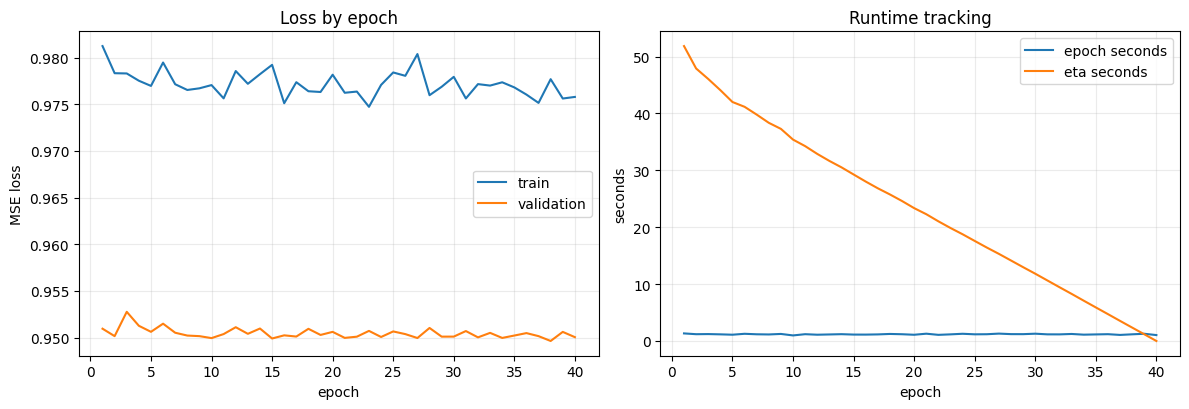

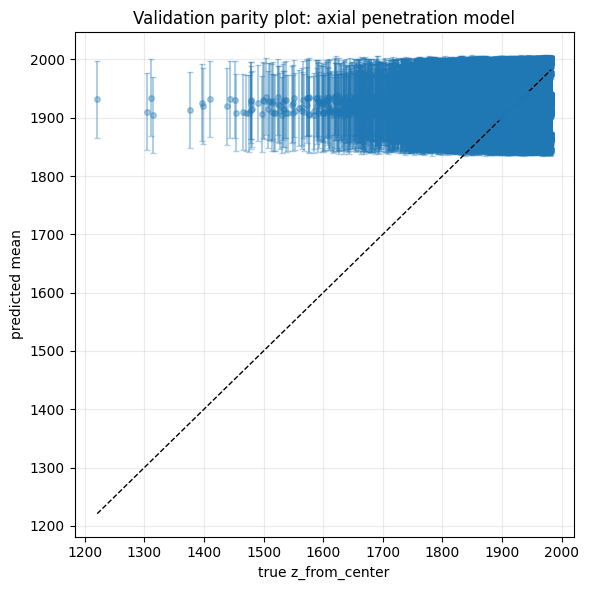

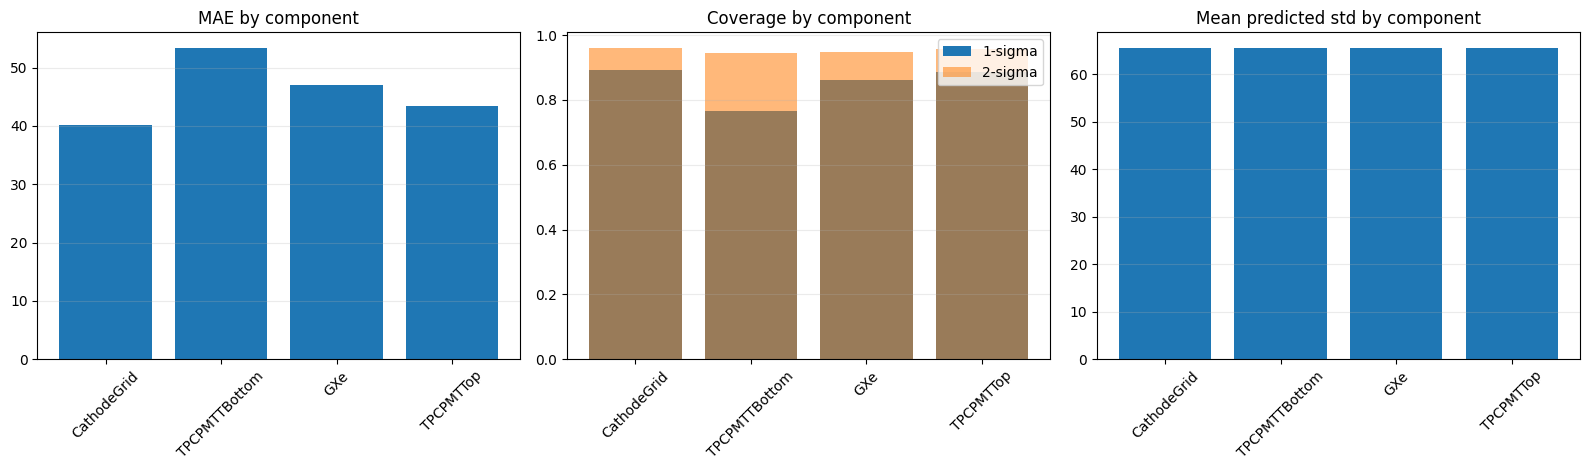

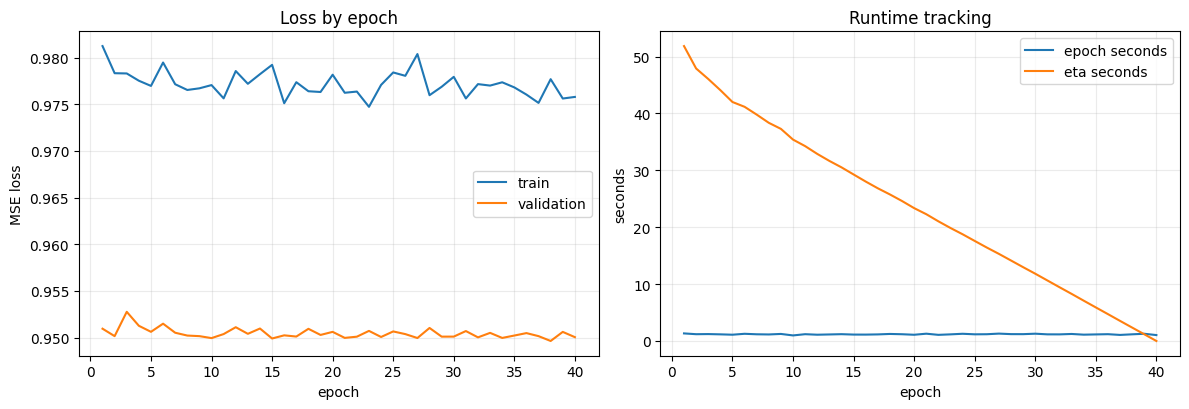

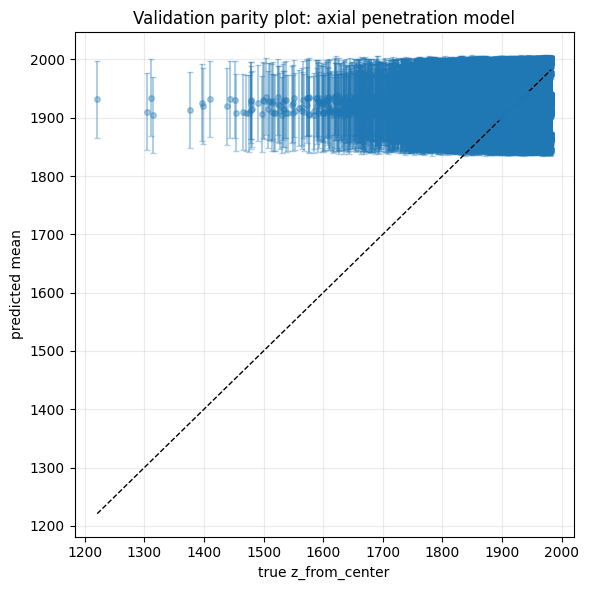

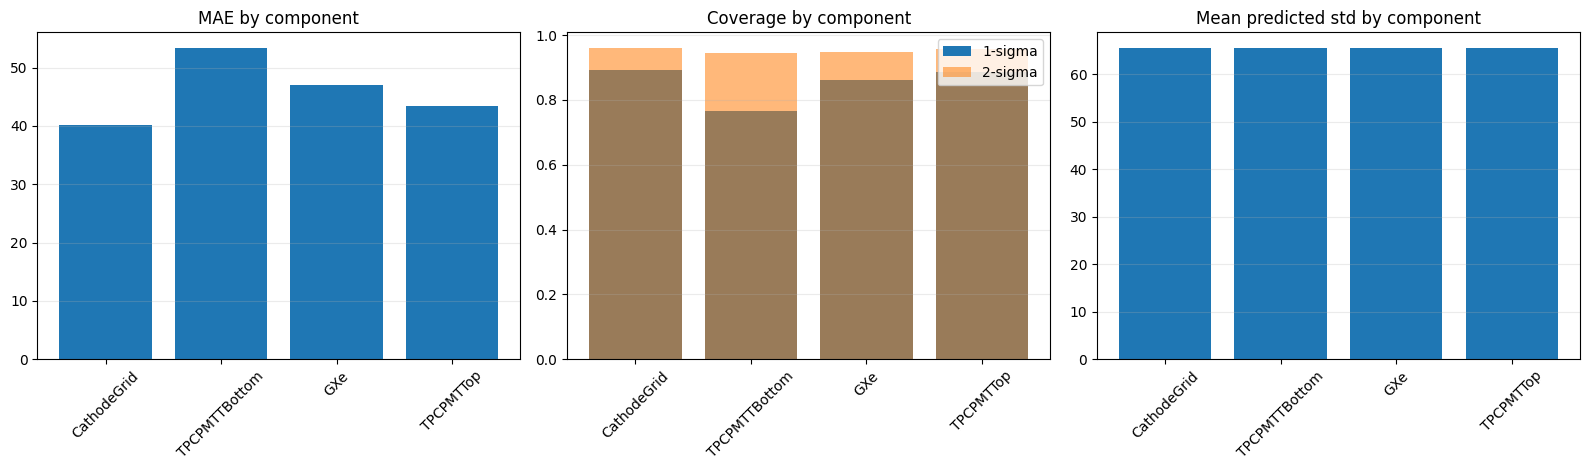

In [5]:
fig = plot_training_history(axial_result.history)
display(fig)
plt.close(fig)

fig = plot_prediction_parity(
    axial_result.prediction_df,
    target_col="z_from_center",
    title="Validation parity plot: axial penetration model",
)
display(fig)
plt.close(fig)

fig = plot_component_error_bars(axial_result.prediction_df)
display(fig)
plt.close(fig)


## 4. Radial-Penetration Data Views

Side components are modeled against radial penetration `r`.

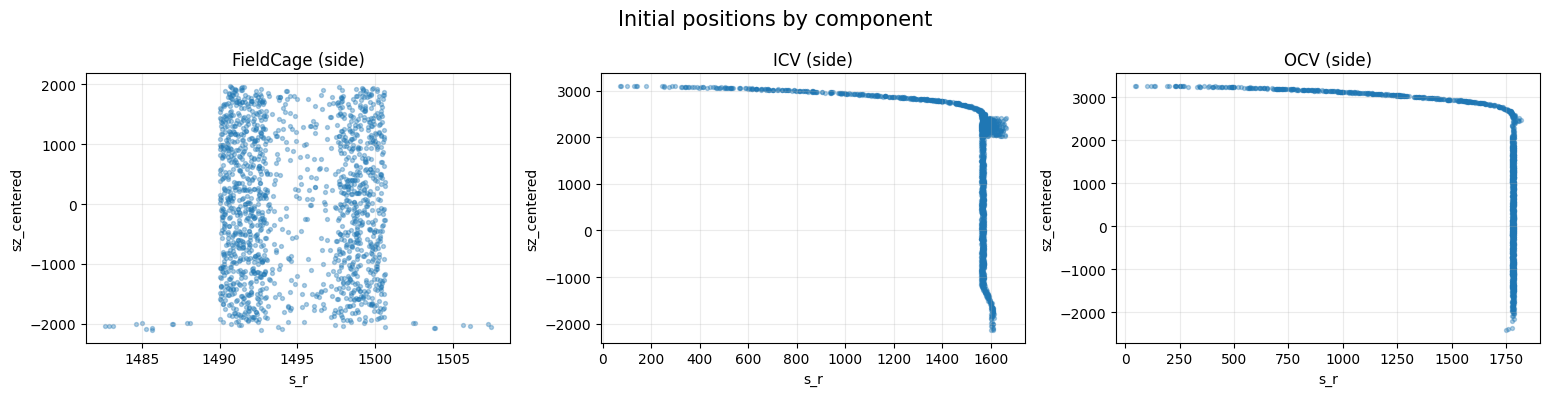

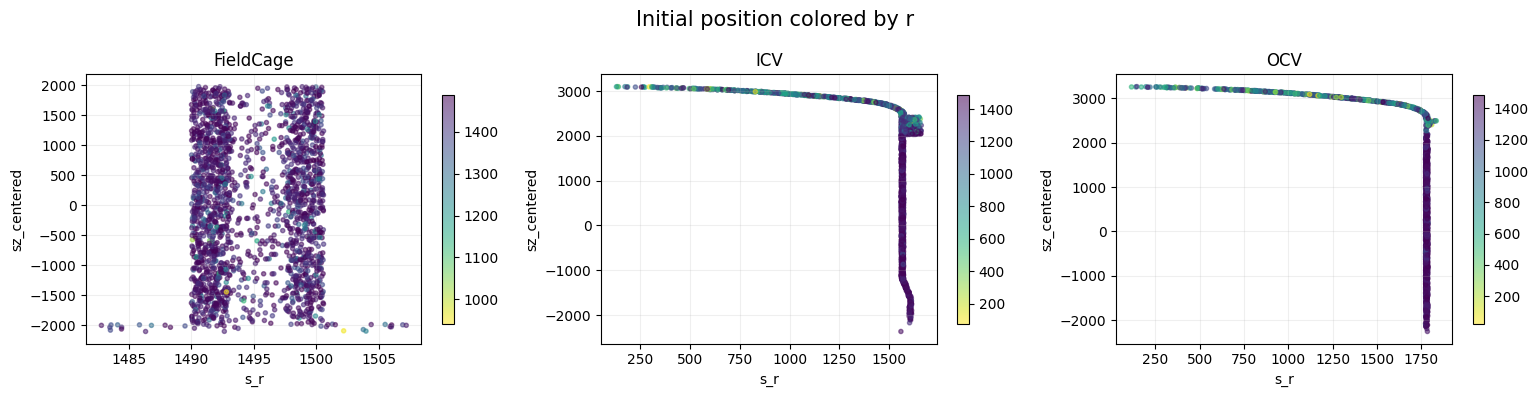

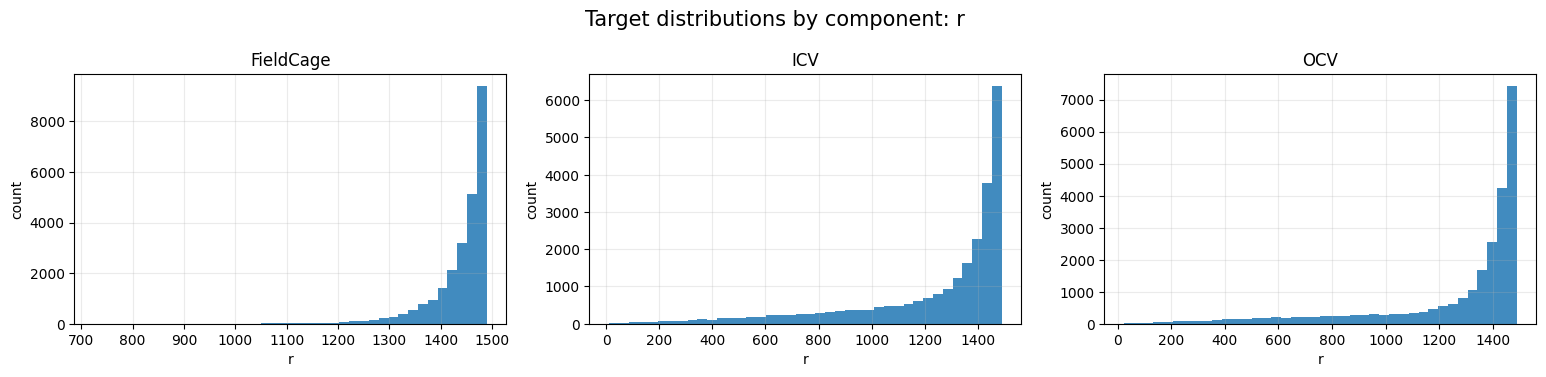

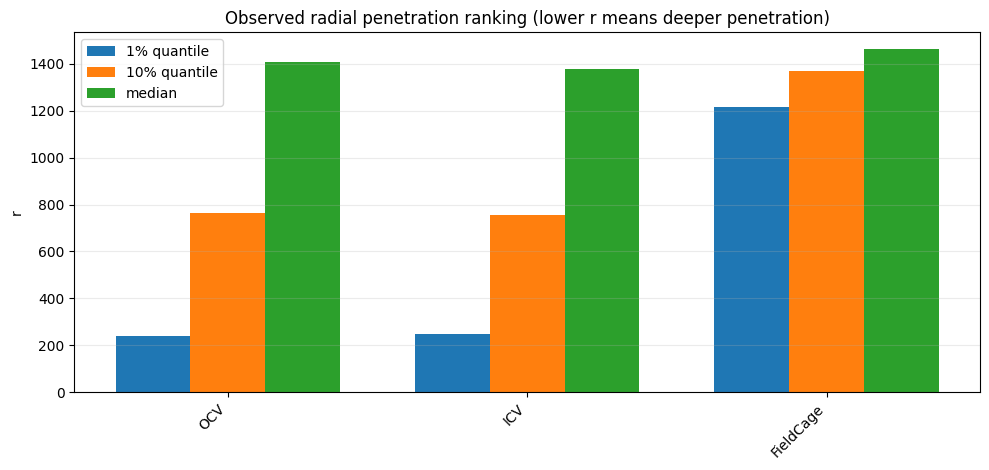

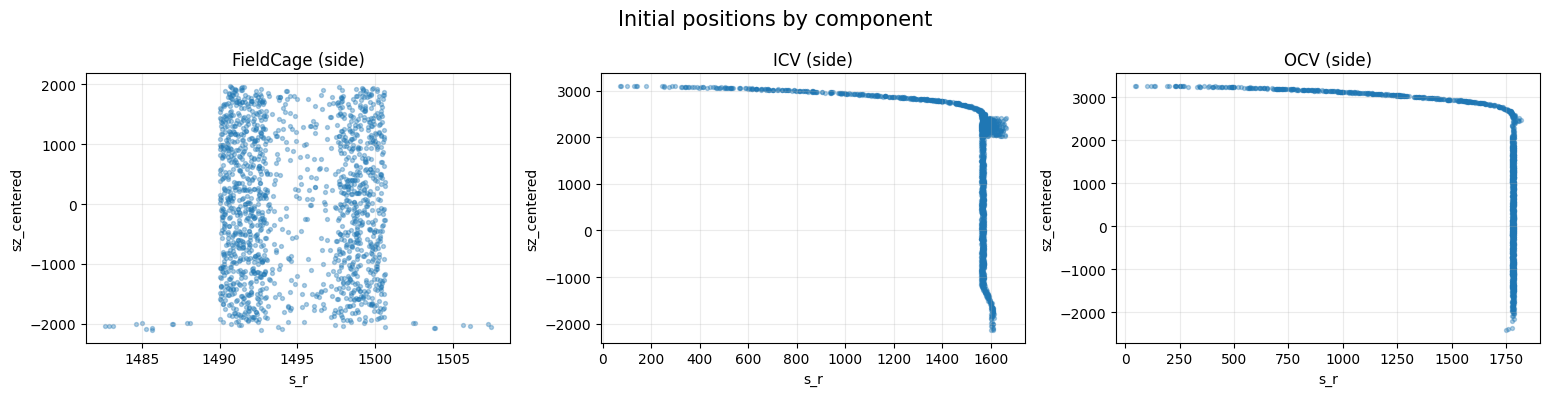

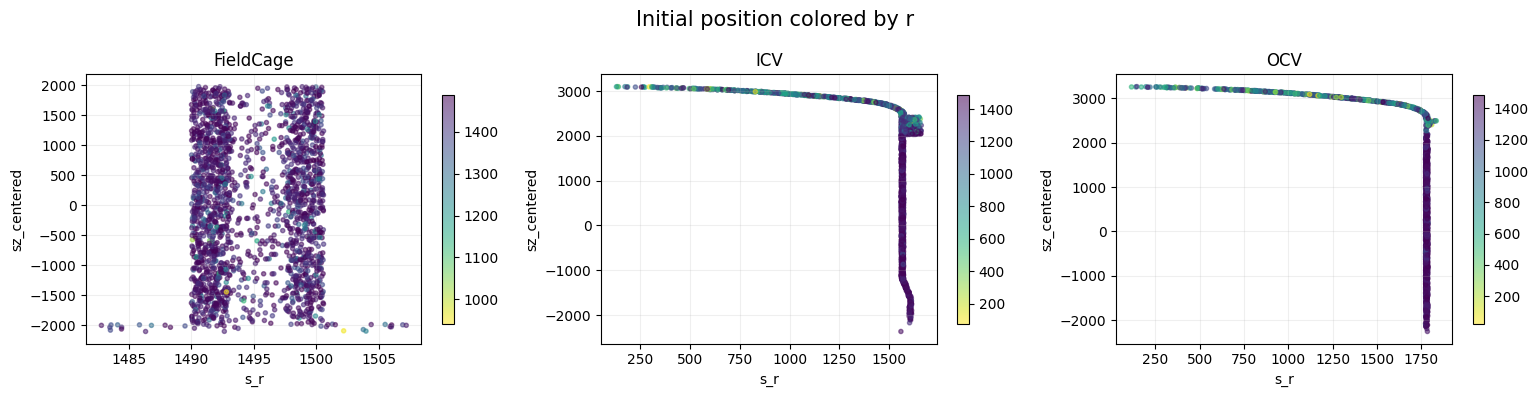

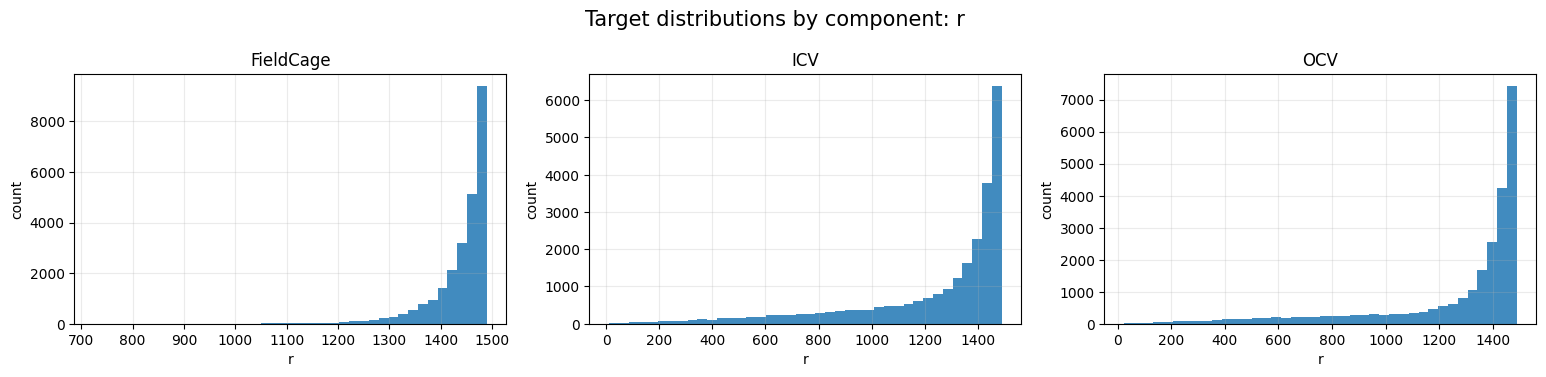

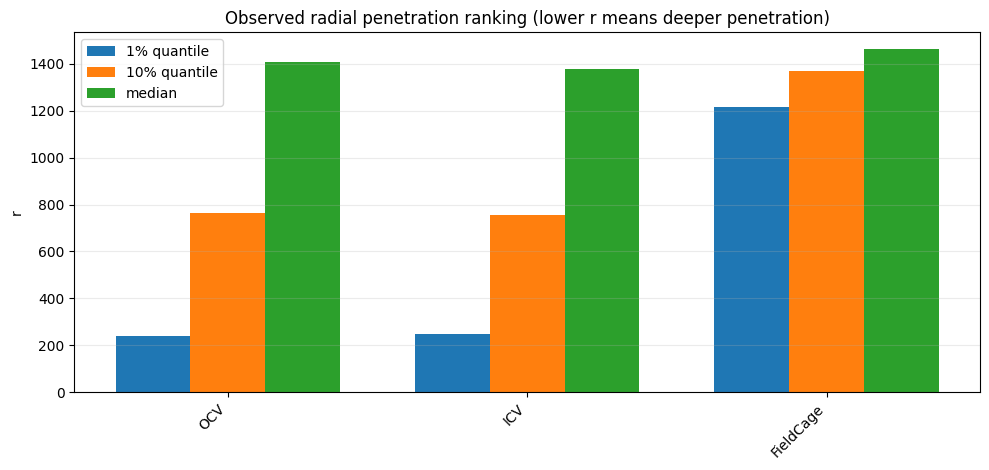

In [6]:
fig = plot_component_initial_positions(radial_df)
display(fig)
plt.close(fig)

fig = plot_component_depth_heatmap(radial_df, target_col="r")
display(fig)
plt.close(fig)

fig = plot_target_distributions(radial_df, target_col="r")
display(fig)
plt.close(fig)

fig = plot_component_penetration_ranking(
    radial_df,
    target_col="r",
    title="Observed radial penetration ranking (lower r means deeper penetration)",
)
display(fig)
plt.close(fig)


## 5. Train The Radial Model

In [7]:
radial_result = run_vbll_regression(
    radial_df,
    target_name="r",
    model_dir=RADIAL_ARTIFACT_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

display(pd.DataFrame([radial_result.metrics]))
print(f"Saved model artifacts: {radial_result.model_dir}")


Training epochs:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 1/40:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2/40:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 3/40:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 4/40:   0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 38/40:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 39/40:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 40/40:   0%|          | 0/118 [00:00<?, ?it/s]

,mae,rmse,r2,coverage_1sigma,coverage_2sigma,mean_pred_std
0,108.858124,182.781778,0.525247,0.809533,0.918467,180.692718


Saved model artifacts: /home/klz/Data/XLZD/anpatnaik/depth_penetration_experiments/artifacts/radial_penetration


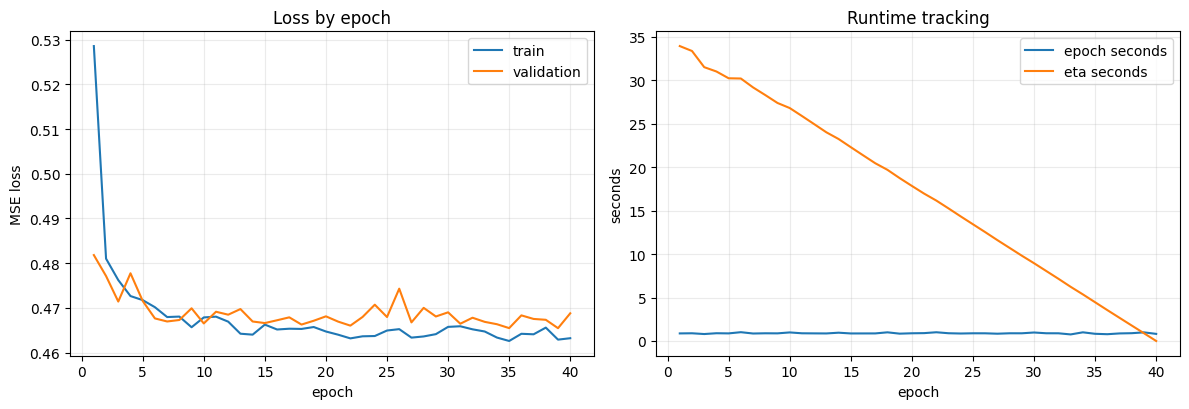

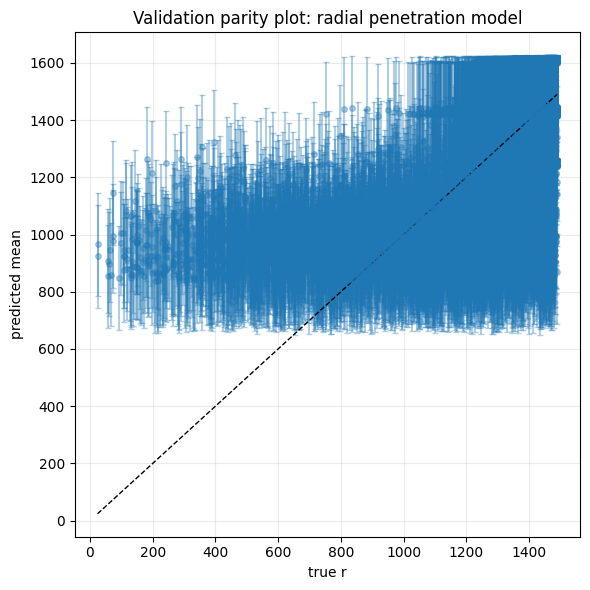

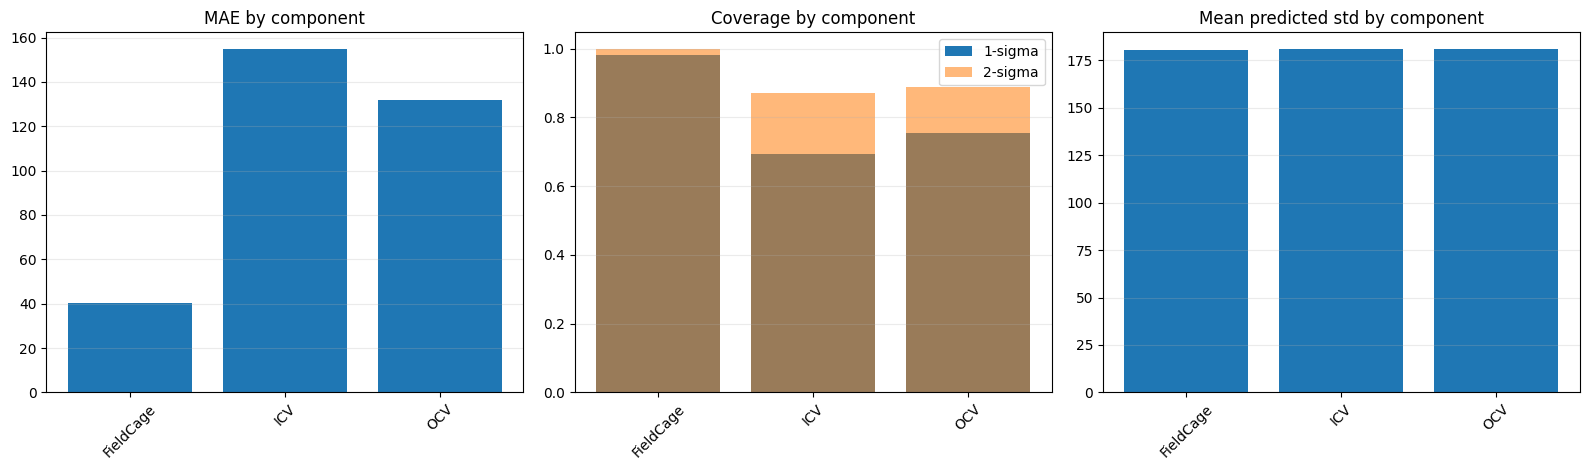

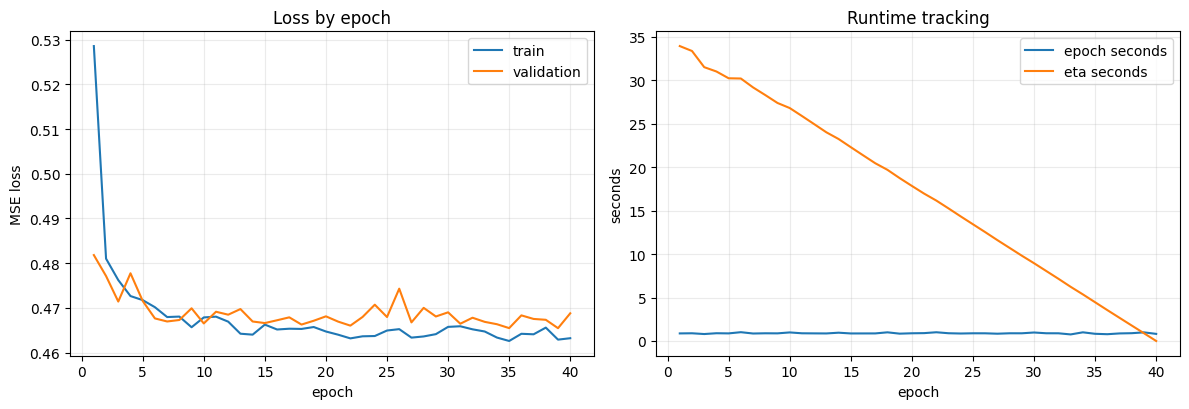

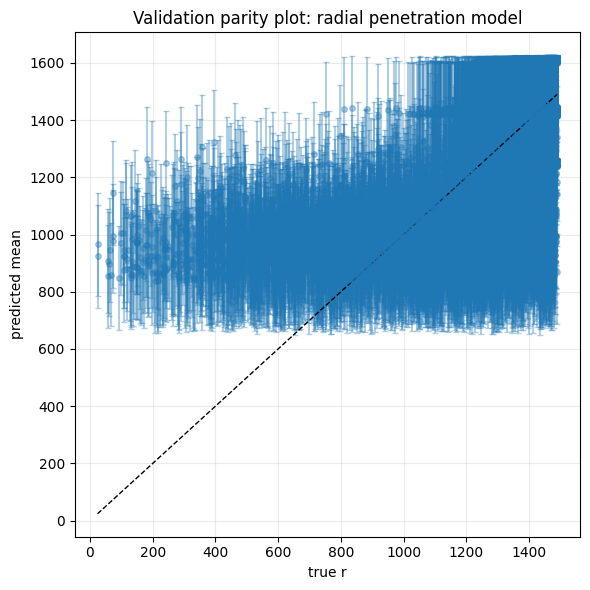

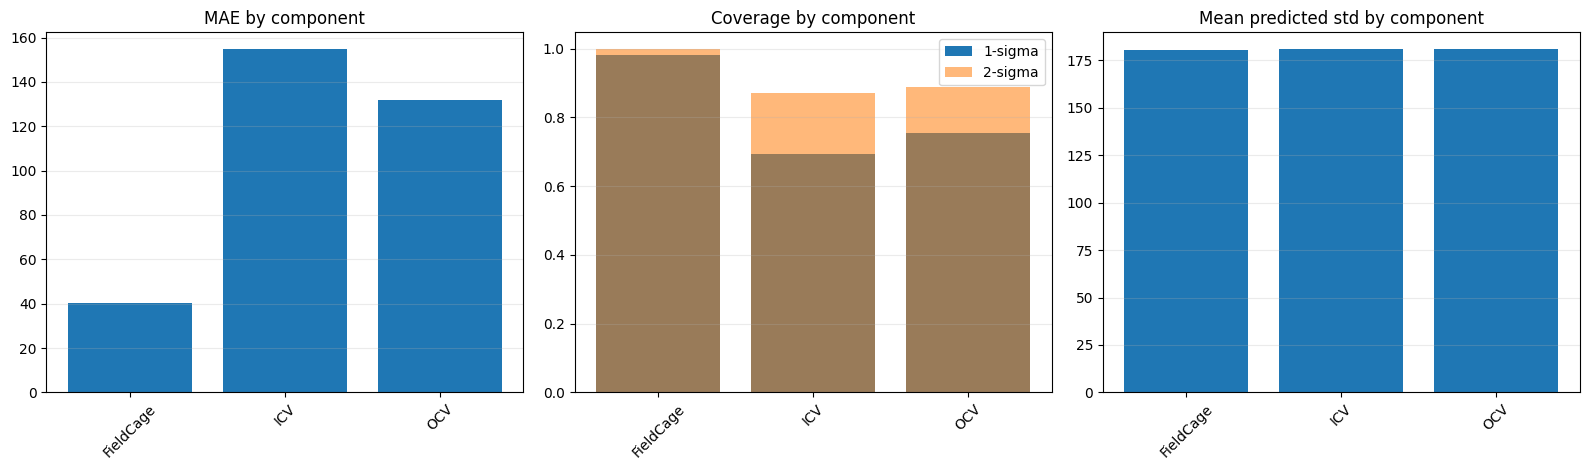

In [8]:
fig = plot_training_history(radial_result.history)
display(fig)
plt.close(fig)

fig = plot_prediction_parity(
    radial_result.prediction_df,
    target_col="r",
    title="Validation parity plot: radial penetration model",
)
display(fig)
plt.close(fig)

fig = plot_component_error_bars(radial_result.prediction_df)
display(fig)
plt.close(fig)


## 6. Compare The Two Grouped Models

In [9]:
comparison_df = pd.DataFrame(
    [
        {"model": "axial", **axial_result.metrics},
        {"model": "radial", **radial_result.metrics},
    ]
)
display(comparison_df)

axial_component_summary = (
    axial_result.prediction_df.groupby(["source_component", "component_group"], dropna=False)
    .agg(mae=("abs_error", "mean"), coverage_1sigma=("within_1sigma", "mean"), coverage_2sigma=("within_2sigma", "mean"))
    .reset_index()
)
radial_component_summary = (
    radial_result.prediction_df.groupby(["source_component", "component_group"], dropna=False)
    .agg(mae=("abs_error", "mean"), coverage_1sigma=("within_1sigma", "mean"), coverage_2sigma=("within_2sigma", "mean"))
    .reset_index()
)

display(axial_component_summary)
display(radial_component_summary)


,model,mae,rmse,r2,coverage_1sigma,coverage_2sigma,mean_pred_std
0,axial,45.993663,65.171839,0.021290,0.851550,0.952500,65.597582
1,radial,108.858124,182.781778,0.525247,0.809533,0.918467,180.692718


,source_component,component_group,mae,coverage_1sigma,coverage_2sigma
0,CathodeGrid,bottom,40.173515,0.8926,0.9606
1,GXe,top,47.035225,0.8628,0.9482
2,TPCPMTTBottom,bottom,53.393650,0.7660,0.9440
3,TPCPMTTop,top,43.372259,0.8848,0.9572


,source_component,component_group,mae,coverage_1sigma,coverage_2sigma
0,FieldCage,side,40.193888,0.9812,0.9974
1,ICV,side,154.607595,0.6922,0.8706
2,OCV,side,131.772888,0.7552,0.8874
